# Ensemble Methods (Code used in the slides)

## Majority Voting

The majority voting code below trains 3 separate decision tree classifiers on the iris dataset, makes predictions on a test set, and combines the predictions through majority vote. This shows a simple way to build an ensemble by combining multiple models. The majority vote ensemble achieves higher test accuracy than the individual classifiers.

In [145]:
from sklearn import model_selection
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import datasets
from mlxtend.classifier import EnsembleVoteClassifier

iris = datasets.load_iris()
X, y = iris.data[:, [0, 3]], iris.target

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.25, random_state=1)

X_train, X_val, y_train, y_val = \
    train_test_split(X_train, y_train, test_size=0.25, random_state=1)

print('Train/Valid/Test sizes:', y_train.shape[0], y_val.shape[0], y_test.shape[0])

clf1 = DecisionTreeClassifier(random_state=1)
clf2 = DecisionTreeClassifier(random_state=1, max_depth=1)
clf3 = DecisionTreeClassifier(random_state=1, max_depth=3)
eclf = EnsembleVoteClassifier(clfs=[clf1, clf2, clf3], weights=[1, 1, 1])

labels = ['Classifier 1', 'Classifier 2', 'Classifier 3', 'Ensemble']
for clf, label in zip([clf1, clf2, clf3, eclf], labels):

    clf.fit(X_train, y_train)
    print("Validation Accuracy: %0.2f [%s]" % (clf.score(X_val, y_val), label))
    
print("Test Accuracy: %0.2f" % eclf.score(X_test, y_test))

Train/Valid/Test sizes: 84 28 38
Validation Accuracy: 0.86 [Classifier 1]
Validation Accuracy: 0.82 [Classifier 2]
Validation Accuracy: 0.93 [Classifier 3]
Validation Accuracy: 0.93 [Ensemble]
Test Accuracy: 0.95


## Bagging

The bagging code below trains a bagging classifier on the iris dataset, made up of 500 decision trees. It demonstrates bagging, where multiple models are trained on random subsets of the data, and their predictions are averaged. This helps reduce variance. The bagging model achieves higher test accuracy than a single decision tree.

In [146]:
from sklearn import model_selection
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.ensemble import BaggingClassifier

iris = datasets.load_iris()
X, y = iris.data[:, [0, 3]], iris.target

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.25, random_state=1)

X_train, X_val, y_train, y_val = \
    train_test_split(X_train, y_train, test_size=0.25, random_state=1)

print('Train/Valid/Test sizes:', y_train.shape[0], y_val.shape[0], y_test.shape[0])

tree = DecisionTreeClassifier(criterion='entropy',
                              random_state=1,
                              max_depth=None)


bag = BaggingClassifier(estimator=tree,
                        n_estimators=500,
                        oob_score=True,
                        bootstrap=True,
                        bootstrap_features=False,
                        n_jobs=1,
                        random_state=1)

bag.fit(X_train, y_train)
    
print("OOB Accuracy: %0.2f" % bag.oob_score_)
print("Test Accuracy: %0.2f" % bag.score(X_test, y_test))

Train/Valid/Test sizes: 84 28 38
OOB Accuracy: 0.93
Test Accuracy: 0.95


In [147]:
tree = DecisionTreeClassifier(criterion='entropy',
                              random_state=1,
                              max_depth=None)

tree.fit(X_train, y_train)

print("Test Accuracy: %0.2f" % tree.score(X_test, y_test))

Test Accuracy: 0.92


In [148]:
tree = DecisionTreeClassifier(criterion='entropy',
                              random_state=1,
                              max_depth=1)

tree.fit(X_train, y_train)

print("Test Accuracy: %0.2f" % tree.score(X_test, y_test))

Test Accuracy: 0.58


## AdaBoost

The AdaBoost code below trains an AdaBoost classifier on the iris dataset, made up of 500 decision trees. It shows AdaBoost, which trains models sequentially, focusing more on misclassified examples. Models added later correct errors from those added earlier. This adapts to the 'hardness' of examples. The AdaBoost model achieves very high test accuracy on the dataset.

In [149]:
from sklearn import model_selection
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.ensemble import AdaBoostClassifier

iris = datasets.load_iris()
X, y = iris.data[:, [0, 3]], iris.target

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.25, random_state=1)

X_train, X_val, y_train, y_val = \
    train_test_split(X_train, y_train, test_size=0.25, random_state=1)

print('Train/Valid/Test sizes:', y_train.shape[0], y_val.shape[0], y_test.shape[0])

tree = DecisionTreeClassifier(criterion='entropy',
                              random_state=1,
                              max_depth=1)


boost = AdaBoostClassifier(estimator=tree,
                           n_estimators=500,
                           algorithm='SAMME',
                           #n_jobs=1,
                           random_state=1)

boost.fit(X_train, y_train)
    
print("Test Accuracy: %0.2f" % boost.score(X_test, y_test))

Train/Valid/Test sizes: 84 28 38


/home/vangelis/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Test Accuracy: 0.97


## Gradient Boosting

The gradient boosting code below trains gradient boosted decision trees on the iris dataset. It demonstrates gradient boosting, which trains models sequentially to fit the residual errors of prior models. This focuses models on hard examples. Gradient boosting achieves high accuracy on the test set.

In [150]:
from sklearn import model_selection
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import datasets

iris = datasets.load_iris()
X, y = iris.data[:, [0, 3]], iris.target

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.25, random_state=1)

X_train, X_val, y_train, y_val = \
    train_test_split(X_train, y_train, test_size=0.25, random_state=1)

print('Train/Valid/Test sizes:', y_train.shape[0], y_val.shape[0], y_test.shape[0])

Train/Valid/Test sizes: 84 28 38


In [151]:
from sklearn.ensemble import GradientBoostingClassifier


boost = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=8,
    random_state=1)

boost.fit(X_train, y_train)
    
print("Test Accuracy: %0.2f" % boost.score(X_test, y_test))

Test Accuracy: 0.95


In [152]:
from sklearn.ensemble import HistGradientBoostingClassifier


boost = HistGradientBoostingClassifier(
    learning_rate=0.1,
    #n_estimators=100,
    max_depth=8,
    random_state=1)

boost.fit(X_train, y_train)
    
print("Test Accuracy: %0.2f" % boost.score(X_test, y_test))

Test Accuracy: 0.97


In [153]:
from sklearn.ensemble import HistGradientBoostingClassifier


boost = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=100,
    early_stopping=True,
    max_depth=8,
    random_state=1)

boost.fit(X_train, y_train)
    
print("Test Accuracy: %0.2f" % boost.score(X_test, y_test))

boost.n_iter_

Test Accuracy: 0.97


52

In [154]:
from sklearn.ensemble import HistGradientBoostingClassifier


boost = HistGradientBoostingClassifier(
    learning_rate=0.5,
    max_iter=100,
    early_stopping=True,
    max_depth=8,
    random_state=1)

boost.fit(X_train, y_train)
    
print("Test Accuracy: %0.2f" % boost.score(X_test, y_test))

boost.n_iter_

Test Accuracy: 0.95


100

In [155]:
# https://xgboost.readthedocs.io/en/latest/build.html
# If xgboost is not installed in your system, install it by uncommenting and running the pip command below:
# !pip install xgboost

In [156]:
import numpy as np
import xgboost as xgb


dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)



param = {
    'max_depth': 8,
    'eta': 0.1,  # learning rate
    'objective': 'multi:softprob',  # loss function for multiclass
    'num_class': 3}  # number of classes

boost = xgb.train(param, dtrain, num_boost_round=100)

y_pred = boost.predict(dtest)
y_labels = np.argmax(y_pred, axis=1)


print("Test Accuracy: %0.2f" % (y_labels == y_test).mean())

Test Accuracy: 0.97


In [157]:
# https://lightgbm.readthedocs.io/en/latest/Installation-Guide.html
# If lightgbm is not installed in your system, install it by uncommenting and running the pip command below:
# !pip install lightgbm

In [158]:
import lightgbm as lgb


boost = lgb.LGBMClassifier(n_estimators=100,
                           max_depth=8,
                           num_leaves=256,  # 2^max_depth
                           random_state=1,
                           learning_rate=0.1,
                           verbose=-1) # to suppress warnings

boost.fit(X_train, y_train)

print("Test Accuracy: %0.2f" % boost.score(X_test, y_test))

Test Accuracy: 0.97


/home/vangelis/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Random Forests

The random forest code below trains a random forest model on the full iris dataset. It shows creating an ensemble using bagging of decision trees, but training each tree on a random subset of features. This decorrelates the trees, further reducing variance. The random forest achieves very high test accuracy.

In [159]:
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn import datasets

iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.25, random_state=1)

X_train, X_val, y_train, y_val = \
    train_test_split(X_train, y_train, test_size=0.25, random_state=1)

print('Train/Valid/Test shapes:', X_train.shape, X_val.shape, X_test.shape)
print('Train/Valid/Test sizes:', y_train.shape[0], y_val.shape[0], y_test.shape[0])

Train/Valid/Test shapes: (84, 4) (28, 4) (38, 4)
Train/Valid/Test sizes: 84 28 38


In [160]:
from sklearn.ensemble import RandomForestClassifier


forest = RandomForestClassifier(n_estimators=100,
                                random_state=1)

forest.fit(X_train, y_train)
    
print("Test Accuracy: %0.2f" % forest.score(X_test, y_test))

Test Accuracy: 0.97


In [161]:
from sklearn.ensemble import ExtraTreesClassifier


forest = ExtraTreesClassifier(n_estimators=100,
                              random_state=1)

forest.fit(X_train, y_train)
    
print("Test Accuracy: %0.2f" % forest.score(X_test, y_test))

Test Accuracy: 0.97


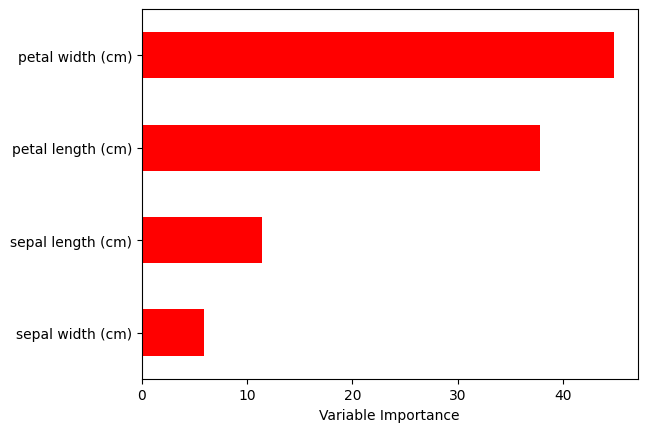

In [162]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(data=X_train, columns=iris.feature_names)

Importance = pd.DataFrame({'Importance': forest.feature_importances_*100}, 
                          index = df.columns)

Importance.sort_values(by = 'Importance', 
                       axis = 0, 
                       ascending = True).plot(kind = 'barh', 
                                              color = 'r', )

plt.xlabel('Variable Importance')
plt.gca().legend_ = None

## Stacking

The stacking code below trains a stack ensemble made up of 5 base models on the iris dataset, with a logistic regression meta-learner. Stacking trains a meta-model to find the best combination of the base models. This ensemble achieves high test accuracy from combining diverse base models.

In [163]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from mlxtend.classifier import StackingClassifier


clf1 = KNeighborsClassifier(n_neighbors=5)
clf2 = RandomForestClassifier(random_state=1)
clf3 = HistGradientBoostingClassifier(random_state=1)
clf4 = AdaBoostClassifier(random_state=1)
clf5 = DecisionTreeClassifier(random_state=1,
                              max_depth=None)

lr = LogisticRegression(random_state=1)

sclf = StackingClassifier(classifiers=[clf1, clf2, clf3, clf4, clf5], 
                          meta_classifier=lr)


sclf.fit(X_train, y_train)
print("Train Accuracy: %0.2f" % sclf.score(X_train, y_train))
print("Test Accuracy: %0.2f" % sclf.score(X_test, y_test))

Train Accuracy: 1.00
Test Accuracy: 0.97


#### Stacking with `sklearn` using cross-validation

In [164]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import StackingClassifier


clf1 = KNeighborsClassifier(n_neighbors=5)
clf2 = RandomForestClassifier(random_state=1)
clf3 = HistGradientBoostingClassifier(random_state=1)
clf4 = AdaBoostClassifier(random_state=1)
clf5 = DecisionTreeClassifier(random_state=1,
                              max_depth=None)

lr = LogisticRegression(random_state=1)

estimators = [('clf1', clf1),
              ('clf2', clf2),
              ('clf3', clf3),
              ('clf4', clf4),
              ('clf5', clf5)]

sclf = StackingClassifier(estimators=estimators, 
                          final_estimator=lr, 
                          cv=10)


sclf.fit(X_train, y_train)
print("Train Accuracy: %0.2f" % sclf.score(X_train, y_train))
print("Test Accuracy: %0.2f" % sclf.score(X_test, y_test))

Train Accuracy: 1.00
Test Accuracy: 0.97
